# Flood Forecaster (Day to Day) — USGS 01543000
### Per-day, per-horizon-calibrated flood risk with ensemble bands, a GloFAS benchmark, and event/real-forecast evaluation

> **v2 additions** (`[v2]` tags below): **§4b** ensemble uncertainty bands · **§6.2** event-based evaluation
> (POD / lead time / false alarms / CSI) · **§6.3** real-forecast backtest (the honest "how good live?") ·
> **§6.4** GloFAS operational benchmark with a mandatory resolution check.

**Basin:** Driftwood Branch Sinnemahoning Creek at Sterling Run, PA (Cameron County; 272 mi² ≈ 705 km²).
Weather: Open-Meteo (ERA5 archive for training; forecast endpoint live). Discharge label: USGS `01543000` QC file.

### Why this is a new build, not a tweak
The prior model predicts one label — *a flood on **any** of days t+1…t+7* — from features that all stop at day *t*.
Two consequences drove this rebuild:
1. **It cannot tell the days apart** — every feature is computed through *t*, so the input is identical no matter
   which horizon you ask about. That is why the old app (correctly) refused to show 7 different numbers.
2. **It ignores the forecast** — the old design deliberately keeps forecast-day rain out of every feature.

This build fixes both: **(1)** a per-day target `flood_on_day[t+h]`; **(2)** a *forecast block* of features built from
the QPF for days t+1…t+h, so each day's risk moves with that day's incoming weather. We train **one pooled
multi-horizon model** (horizon *h* is a feature) that emits all 7 per-day risks, and keep a separate **windowed
model** for an honest headline.

## 1. Data, label, and the flood threshold

In [1]:
import json, numpy as np, pandas as pd, joblib
from pathlib import Path
from features import (ANTECEDENT, FORECAST, HORIZON, FEATURES_A, FEATURES_B, HORIZONS,
                      antecedent_features, make_horizon_rows)
from train_daybyday import load_data, build_pooled, split_masks, cfs_to_mm_per_day, BASIN

DATA = Path("data"); MODELS = Path("models"); FIG = Path("figures")
df = load_data()
train_years = df[df["date"].dt.year <= 2004]
threshold = float(np.percentile(train_years["q_cfs"], 98))
thr_mm = cfs_to_mm_per_day(threshold, BASIN["area_km2"])
print(f"records: {len(df)}  {df.date.min().date()}..{df.date.max().date()} (no missing days)")
print(f"flood threshold = 98th pct(1980-2004) = {threshold:.1f} cfs = {thr_mm:.2f} mm/day")
print(f"1-day base rate over full record = {(df.q_cfs>=threshold).mean():.4%}")

records: 12784  1980-01-01..2014-12-31 (no missing days)
flood threshold = 98th pct(1980-2004) = 2543.8 cfs = 8.83 mm/day
1-day base rate over full record = 2.0729%


**Per-day label:** `flood_on_day[k] = q_cfs[k] >= threshold`. A flood day sits at the **98th percentile of
1980–2004 flow** (~2% of days) — low and imbalanced, which drives the metric choices (lead with PR-AUC, recall
and calibration, not accuracy).

## 2. Three feature blocks (the split is load-bearing for leakage)

| Block | Window | Train fill | Serve fill |
|---|---|---|---|
| **A. Antecedent** (≤ t) | rolling rain 1/3/7/14/30, EWMA, tmax/tmin/tmax_3d, season of *t* | observed ERA5 | Open-Meteo `past_days` |
| **B. Forecast** (t+1…t+h) | `fc_rain_cum/on_h/prev1/prev2/max`, `fc_tmax_on_h` | **observed** ERA5 rain (*perfect-prog*) | **real** Open-Meteo `forecast_days` |
| **C. Horizon** | `horizon` h∈1…7, season of target day t+h | — | — |

The **forecast block is the only place a forecast-day value may enter**. It is filled from *observed* rain at
train time (a perfect-forecast proxy) and the *real* forecast at serve time. The antecedent block stays strictly
backward-looking, so no forecast value ever leaks into it. One shared builder (`make_horizon_rows`) is used for
both training and serving, so train/serve features cannot drift.

## 3. Pooled dataset, chronological split, 7-day embargo

In [2]:
pooled = build_pooled(df, threshold)
m = split_masks(pooled["anchor_date"])
embargo_days = pd.to_datetime(pooled.loc[m["embargo"], "anchor_date"]).nunique()
print(f"pooled rows: {len(pooled):,}  from {pooled.anchor_date.nunique():,} anchor days x {len(HORIZONS)} horizons")
assert embargo_days == 7
print(f"embargo: exactly {embargo_days} anchor days dropped at the 2004/2005 boundary")
for name in ("fit","val","test"):
    d = pd.to_datetime(pooled.loc[m[name],"anchor_date"])
    print(f"  {name:4s}: {d.min().date()}..{d.max().date()}  ({d.nunique()} anchor days)")
print(f"per-day flood rate: train {pooled.loc[m['fit']|m['val'],'flood_on_day'].mean():.4%}"
      f" | test {pooled.loc[m['test'],'flood_on_day'].mean():.4%}")

pooled rows: 89,236  from 12,748 anchor days x 7 horizons
embargo: exactly 7 anchor days dropped at the 2004/2005 boundary


  fit : 1980-01-30..2001-12-31  (8007 anchor days)
  val : 2002-01-01..2004-12-24  (1089 anchor days)
  test: 2005-01-01..2014-12-24  (3645 anchor days)
per-day flood rate: train 2.0119% | test 2.2497%


**Leakage-safe CV/split (the key correctness point):** the 7 rows of one anchor day are near-duplicates, so
we split by **anchor day, chronologically**, keeping all 7 horizon-rows of a day in the same fold (never a random
row split). Hyperparameters were tuned with **anchor-day expanding-window time folds** scoring average precision.

## 4. Results — per-horizon test metrics (2005–2014, calibrated)

In [3]:
summary = json.loads((DATA/"metrics_summary.json").read_text())
mA = pd.DataFrame(summary["metricsA"])
mA_disp = mA.assign(horizon=mA.horizon.astype(str))
mA_disp.style.format({c:"{:.4f}".format for c in
    ["base_rate","roc_auc","pr_auc","recall","precision","f1","brier"]}, na_rep="—")

,horizon,base_rate,roc_auc,pr_auc,recall,precision,f1,brier,n,n_pos
0,1,0.0225,0.9328,0.2818,0.9756,0.0428,0.0821,0.0187,3645,82
1,2,0.0225,0.9204,0.2418,0.9390,0.0827,0.1520,0.0200,3645,82
2,3,0.0225,0.9138,0.2606,0.9512,0.0633,0.1187,0.0195,3645,82
3,4,0.0225,0.9047,0.2493,0.9634,0.0513,0.0975,0.0203,3645,82
4,5,0.0225,0.9196,0.2606,0.9634,0.0500,0.0951,0.0196,3645,82
5,6,0.0225,0.9201,0.2927,0.9634,0.0504,0.0958,0.0184,3645,82
6,7,0.0225,0.9237,0.2960,0.9146,0.1003,0.1807,0.0179,3645,82
7,ALL,0.0225,0.9207,0.2867,—,—,—,0.0192,25515,574


In [4]:
bundleA_meta = joblib.load(MODELS/"flood_daybyday_model.joblib")["metadata"]
print("aggregate ROC-AUC=%.3f  PR-AUC=%.3f" % (mA.iloc[-1].roc_auc, mA.iloc[-1].pr_auc))
print("Model B (+q_t) near-h1 PR-AUC=%.3f vs A %.3f (today's discharge sharpens the near horizons)"
      % (summary["metricsB"][0]["pr_auc"], summary["metricsA"][0]["pr_auc"]))
print("LR pooled baseline PR-AUC=%.3f" % bundleA_meta["lr_baseline_pooled_pr_auc"])
print("chosen HGB config: %s  |  anchor-day CV AP: %s" % (
    bundleA_meta["chosen_config"], {k: round(v,4) for k,v in bundleA_meta["cv_scores"].items()}))

aggregate ROC-AUC=0.921  PR-AUC=0.287
Model B (+q_t) near-h1 PR-AUC=0.564 vs A 0.282 (today's discharge sharpens the near horizons)
LR pooled baseline PR-AUC=0.339
chosen HGB config: hgb_a  |  anchor-day CV AP: {'hgb_a': 0.2948, 'hgb_b': 0.2918}


### Skill gradient — and why it looks flat here


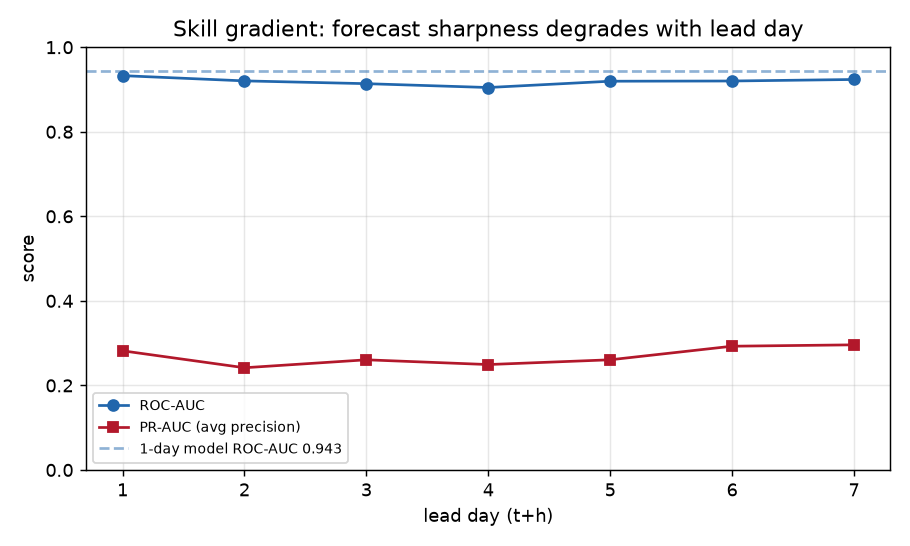

In [5]:
from IPython.display import Image, display
display(Image(str(FIG/"skill_gradient.png")))

The held-out skill gradient is roughly **flat** — *because* the forecast block is trained **and** tested on
**observed (perfect) rain**. That flatters the far horizons. The *true* lead-day degradation only appears once
the forecast is made imperfect (§6 stress test). This is exactly honesty fact #2 made visible.

### Per-horizon reliability (calibrated)

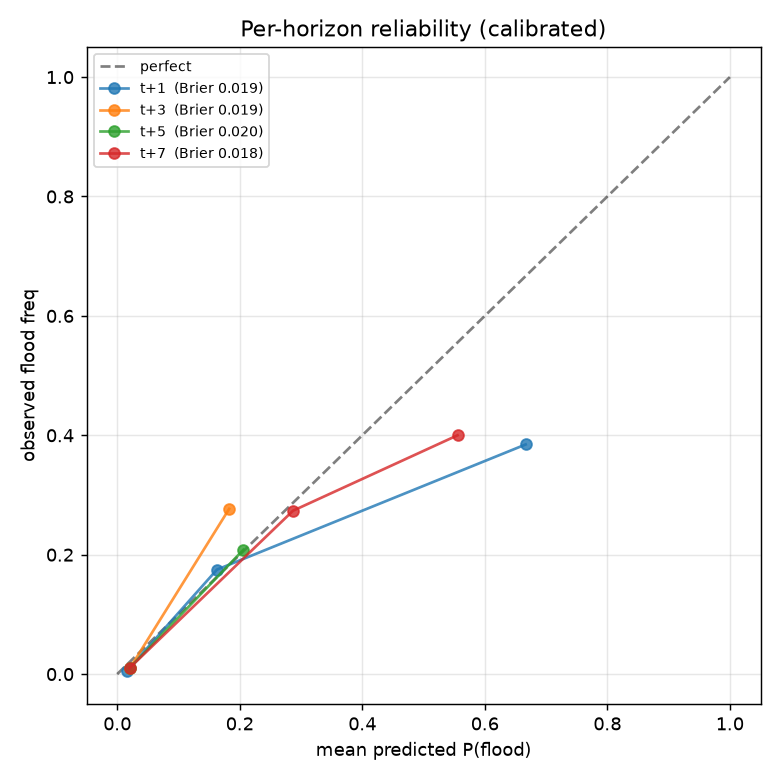

In [6]:
display(Image(str(FIG/"reliability_per_horizon.png")))

Each displayed daily **X%** is a per-horizon *isotonic-calibrated* probability — it means roughly that
historical flood rate for days like this. Near horizons calibrate tighter than far ones. Brier per horizon is in
the metrics table above.

### Coefficient / importance story

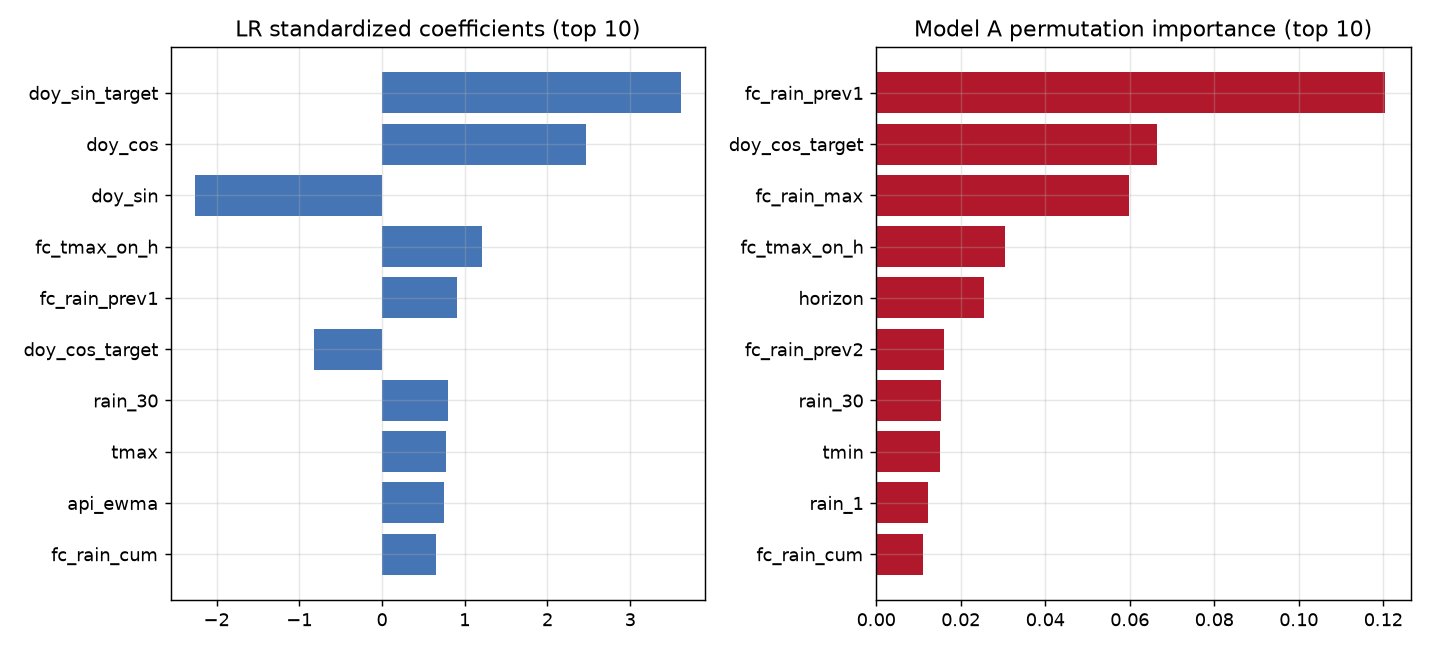

Model A top permutation importances:
  fc_rain_prev1    0.120
  doy_cos_target   0.066
  fc_rain_max      0.060
  fc_tmax_on_h     0.030
  horizon          0.026
  fc_rain_prev2    0.016


In [7]:
display(Image(str(FIG/"feature_importance.png")))
print("Model A top permutation importances:")
for k,v in list(summary["perm_importance"].items())[:6]: print(f"  {k:16s} {v:.3f}")

The **forecast-block rain features carry real weight** at the horizons they cover (`fc_rain_prev1`,
`fc_rain_max`, `fc_rain_prev2`), alongside antecedent seasonality and temperature — nothing perverse
(no "more forecast rain → lower risk").

## 5. The honest headline — a separate windowed model

windowed 'flood_within7' headline:
  base rate 8.78% | ROC-AUC 0.788 | PR-AUC 0.280 | recall 0.93 precision 0.13


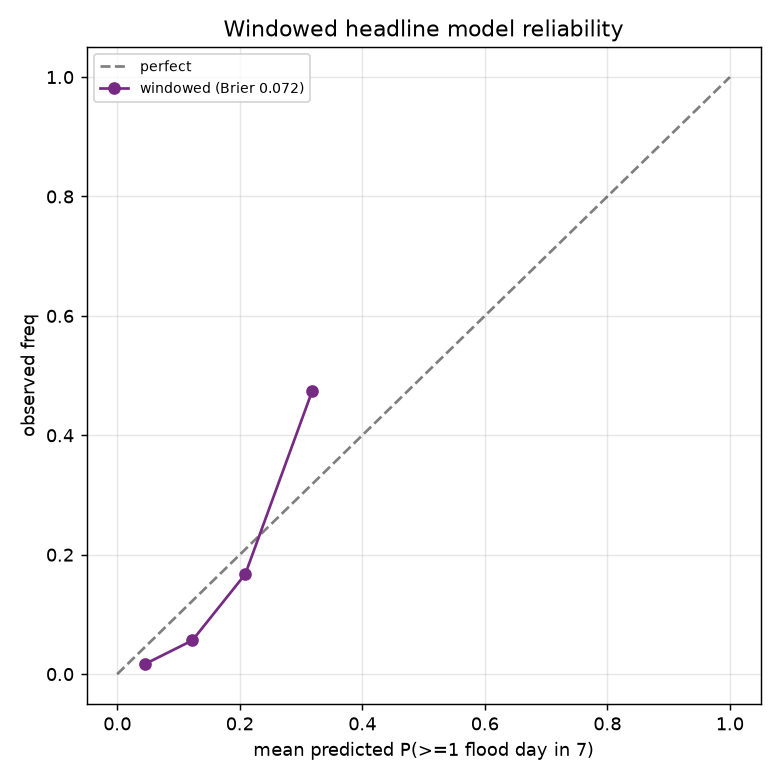

In [8]:
wm = joblib.load(MODELS/"flood_windowed_model.joblib")["metadata"]["metrics"]
print("windowed 'flood_within7' headline:")
print(f"  base rate {wm['base_rate']:.2%} | ROC-AUC {wm['roc_auc']:.3f} | PR-AUC {wm['pr_auc']:.3f}"
      f" | recall {wm['recall']:.2f} precision {wm['precision']:.2f}")
display(Image(str(FIG/"windowed_calibration.png")))

We **do not** multiply the 7 per-day probabilities for the headline — floods cluster across consecutive
days, so an independence formula would be biased. Instead a **separately-calibrated windowed model** supplies the
"≥ 1 flood day in the next 7 days" number, and the 7 daily bars are the "which days" breakdown. They agree in
spirit but are not arithmetically identical (different models).

**Comparison (mind the scales):** the windowed ROC-AUC (printed above, ≈ 0.79) vs the published **1-day model
0.943** and the prior **"flood within 7 days" build ≈ 0.79**. Different targets and base rates → *not* directly
comparable; a 1-day task is easier than a per-day 7-day-ahead one.

## 6. Forecast-degradation stress test (bounds the hindcast optimism)

,horizon,pr_auc_perfect,pr_auc_degraded
0,1,0.282,0.286
1,2,0.242,0.239
2,3,0.261,0.205
3,4,0.249,0.215
4,5,0.261,0.182
5,6,0.293,0.213
6,7,0.296,0.178


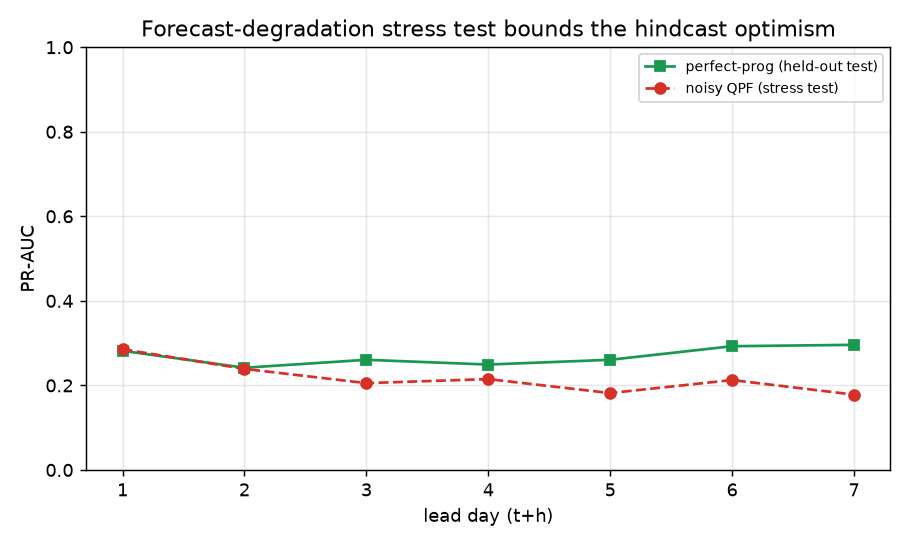

In [9]:
sdf = pd.DataFrame(summary["stress"])
display(sdf.style.format({"pr_auc_perfect":"{:.3f}".format,"pr_auc_degraded":"{:.3f}".format}))
display(Image(str(FIG/"forecast_degradation.png")))

Re-scoring the test set with **noisy QPF** (multiplicative error growing with lead day) turns the optimism
caveat from a hand-wave into a number: PR-AUC falls further at longer leads. **This is the honest lead-day
gradient** live users experience — the flat perfect-prog curve is not.

## 6.2 `[v2]` Event-based evaluation — does it warn in time? (POD is never shown alone)
A flood **event** = a maximal run of consecutive flood days (merging runs ≤1 day apart). **POD 0.95 is
inflated by the alert rate**: the primary operating point alerts on ~half of all days, so events get "caught a
week out" by ambient alerting, not anticipation. So POD is always reported beside the **false-alarm ratio** and
the **alert frequency**, at **two operating points** — the recall-targeted *primary* and a stricter
*high-confidence* threshold derived on the **validation fold** (~2% alert rate).

41 flood events, 2005-2014


,operating point,POD_7day,false_alarm_ratio,alert_frequency,CSI,median_lead_days
0,primary (recall),0.95,0.84,0.51,0.16,7
1,high-confidence (~2%),0.78,0.56,0.13,0.35,7


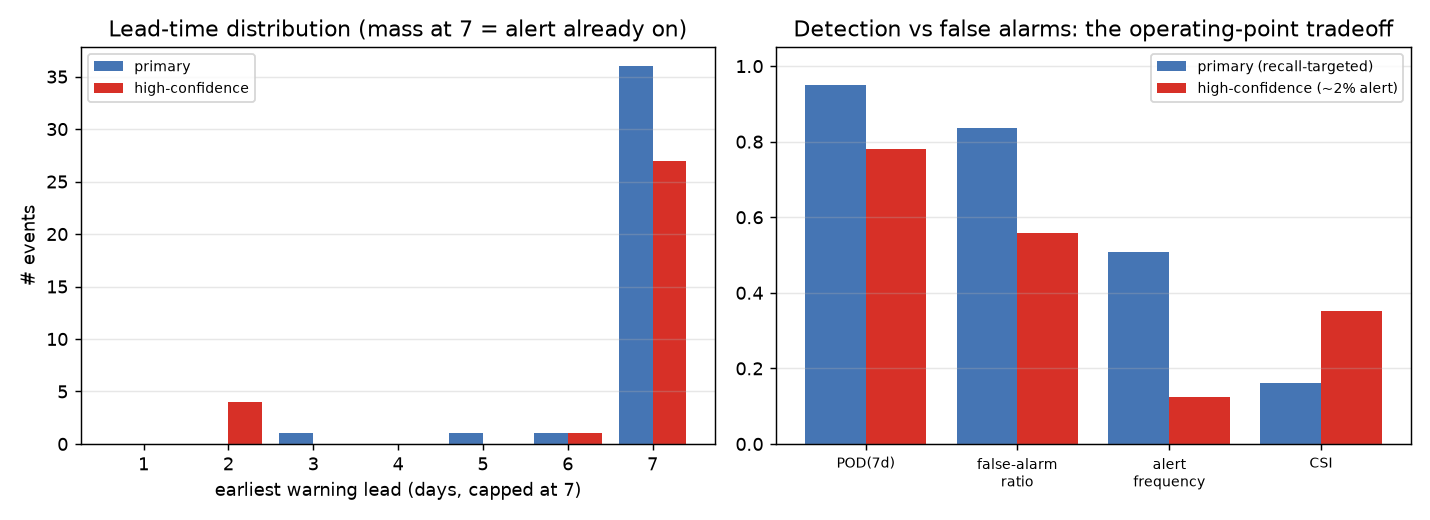

In [10]:
v2 = json.loads((DATA/"v2_summary.json").read_text())
ev = v2["event"]; pr, hc = ev["primary"], ev["high_confidence"]
tbl = pd.DataFrame([
    {"operating point":"primary (recall)", **{k:pr[k] for k in
        ["POD_7day","false_alarm_ratio","alert_frequency","CSI","median_lead_days"]}},
    {"operating point":"high-confidence (~2%)", **{k:hc[k] for k in
        ["POD_7day","false_alarm_ratio","alert_frequency","CSI","median_lead_days"]}}])
print(f"{pr['n_events']} flood events, 2005-2014")
display(tbl.style.format({"POD_7day":"{:.2f}","false_alarm_ratio":"{:.2f}","alert_frequency":"{:.2f}",
                          "CSI":"{:.2f}","median_lead_days":"{:.0f}"}))
display(Image(str(FIG/"event_evaluation.png")))

**Lead time is capped at 7 days by construction**, so a median of 7 means the mass is saturated at the cap
(the alert was already on) — not that the model resolves timing. The high-confidence column is the honest cost
of fewer false alarms: lower detection and shorter lead. Both inherit the perfect-prog optimism (the model sees
exact rain); the real-forecast backtest next is the honest live view.

## 6.3 `[v2]` Real-forecast backtest — the honest "how good live?"
The held-out metrics use the perfect-prog proxy. Here we rebuild the forecast block from **real archived
forecasts** (Open-Meteo Historical Forecast API) on a recent window with **USGS observed** labels, and compare
per-horizon skill to the perfect-prog proxy on the *same* anchors.

window 2022-01-01..2024-12-24 | 119 flood targets | archived-forecast vs observed rain r=0.57


,horizon,n_pos,pr_auc_perfect,pr_auc_real,recall_perfect,recall_real
0,1,17,0.482,0.472,1.00,1.00
1,2,17,0.388,0.347,1.00,0.94
2,3,17,0.409,0.295,1.00,1.00
3,4,17,0.357,0.252,1.00,1.00
4,5,17,0.387,0.317,1.00,1.00
5,6,17,0.404,0.309,1.00,1.00
6,7,17,0.374,0.268,0.94,0.88


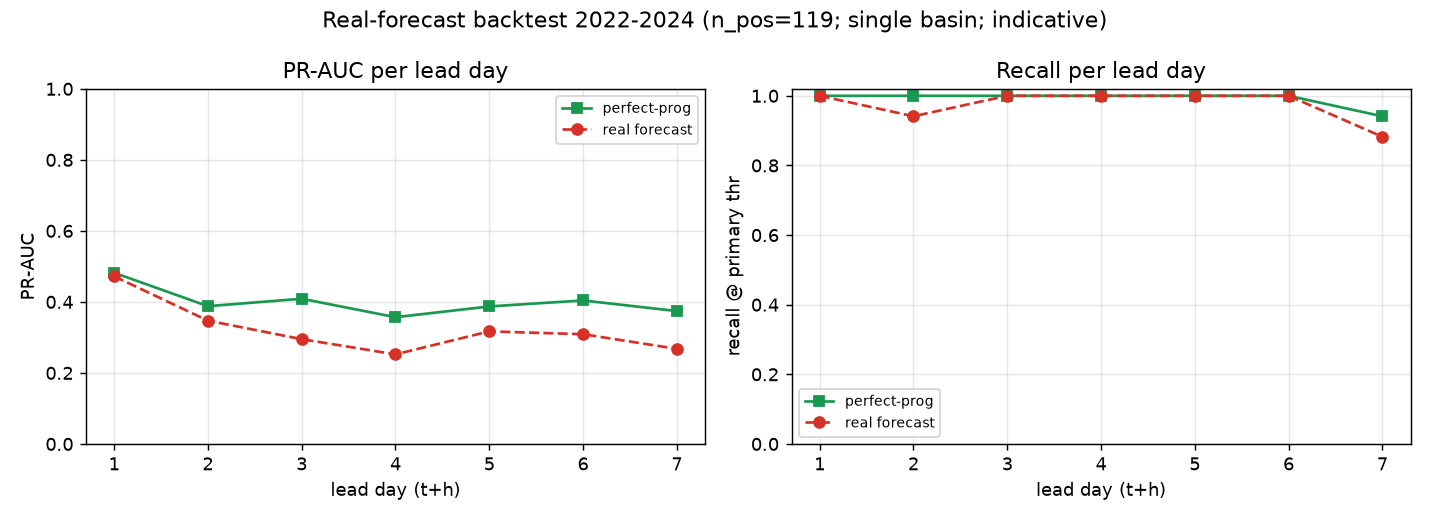

Real archived forecasts (rain corr 0.57 with observed) vs the perfect-prog proxy on the same anchors/labels. Small, single-basin, recent sample -> indicative; the synthetic degradation test spans all leads on 2005-2014.


In [11]:
rf = v2["real_forecast"]
if rf:
    rfd = pd.DataFrame(rf["per_horizon"])
    print(f"window {rf['window'][0]}..{rf['window'][1]} | {rf['n_pos']} flood targets"
          f" | archived-forecast vs observed rain r={rf['archived_fc_vs_obs_rain_corr']:.2f}")
    display(rfd[["horizon","n_pos","pr_auc_perfect","pr_auc_real","recall_perfect","recall_real"]]
            .style.format({c:"{:.3f}".format for c in ["pr_auc_perfect","pr_auc_real"]}
                          | {c:"{:.2f}".format for c in ["recall_perfect","recall_real"]}, na_rep="—"))
    display(Image(str(FIG/"real_forecast_backtest.png")))
    print(rf["note"])
else:
    print("real-forecast backtest unavailable; the synthetic degradation test (§6) spans all leads.")

**This is the money plot — per horizon, not just the aggregate 0.40→0.32.** Day+1 holds up under real
forecasts; the far horizons drop most (both PR-AUC and recall). That declining real-forecast curve is what a
live user experiences; the flat perfect-prog gradient is not. Small single-basin recent sample → indicative;
the synthetic degradation test (§6) brackets all leads on the full 2005-2014 period.

## 6.4 `[v2]` External benchmark — GloFAS reanalysis (are we near the operational standard?)
GloFAS is the operational global flood model (~5 km). At ~5 km it may **mis-resolve** a 705 km² creek, so a
resolution sanity check is mandatory before any comparison.

resolution check: exact-coord GloFAS mean 0.35 m3/s vs USGS 13.0 m3/s -> nudged coords [0.1, -0.1] -> 11.0 m3/s (resolved)
MATCHED operating point (fair): at GloFAS FAR=0.54 (alert-freq 0.02), GloFAS POD=0.41 vs model (h=1) POD=0.19 at the same FAR


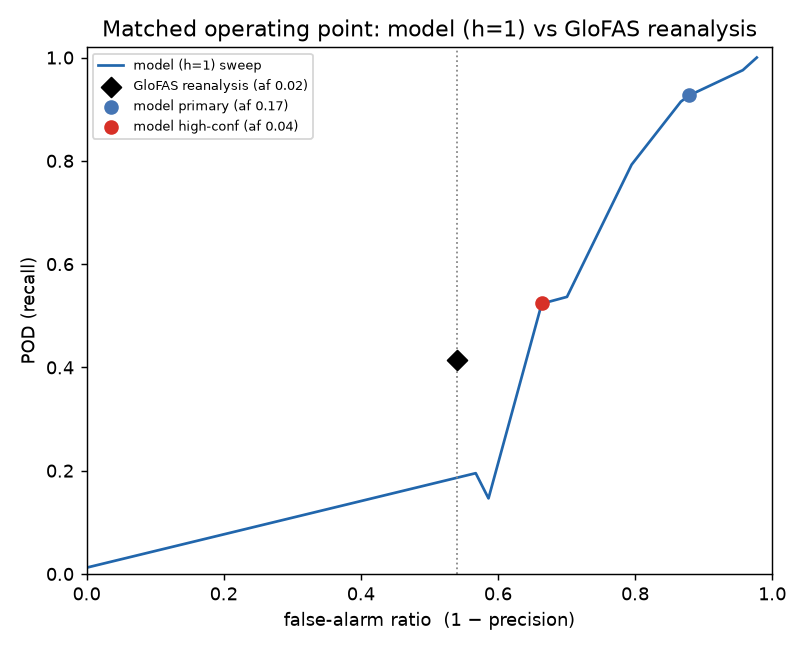

In [12]:
gb = v2["glofas"]; gm = v2.get("glofas_matched")
if gb:
    print(f"resolution check: exact-coord GloFAS mean {gb['base_coord_mean_m3s']:.2f} m3/s vs USGS "
          f"{gb['usgs_mean_m3s']:.1f} m3/s -> nudged coords {gb['offset']} -> {gb['chosen_mean_m3s']:.1f} m3/s "
          f"({'INDICATIVE' if gb['indicative'] else 'resolved'})")
if gm:
    print(f"MATCHED operating point (fair): at GloFAS FAR={gm['glofas']['FAR']:.2f} "
          f"(alert-freq {gm['glofas']['alert_freq']:.2f}), GloFAS POD={gm['glofas']['POD']:.2f} "
          f"vs model (h=1) POD={gm['model_pod_at_glofas_far']:.2f} at the same FAR")
    display(Image(str(FIG/"glofas_matched.png")))

Bare CSI numbers were apples-to-oranges (different alert rates), so we compare on **POD-vs-FAR**. At
GloFAS's false-alarm ratio, **GloFAS-reanalysis detects more than the model's shortest-lead prediction** — an
honest result: GloFAS *reanalysis* (observed forcing) is a strong upper-bound reference, and this ML build does
not beat it. This is GloFAS **reanalysis**, **not** a forecast benchmark (that needs reforecasts; see README);
units converted m³/s→cfs; the exact-coord magnitude (~0.35 m³/s) was implausibly small so the ~5 km grid's
reach was nudged to match the USGS scale.

## 4b `[v2]` Ensemble uncertainty bands (how the live band is built)
At serve time the app fetches the **gfs_seamless** ensemble (~31 members). The shared observed antecedent is
held fixed and **each member's forecast-window rain** is pushed through the same model + per-horizon
calibrators, giving one calibrated p_h per member. The displayed bar is the **median**, the whisker the
**P10–P90**, and "N/M" the members above threshold. **It captures forecast-input spread only** — not model
error or antecedent-source uncertainty — so the true range is wider (honesty fact #4). A network-free parity
self-test in `live_data.py` confirms identical members reproduce the deterministic path and the aggregation is
correct.

## 7. Honesty facts (non-negotiable)
0. **Every displayed per-day number is a per-horizon-calibrated probability**, not a raw score.
1. **Reliability decreases with lead day** — partly inherent uncertainty, partly because **QPF skill degrades
   with lead time**.
2. **Live skill is optimistically estimated by the held-out metrics — most at far horizons** (perfect-prog
   train vs imperfect real forecast). §6.3 measures the gap; §6 brackets it.
3. **Per-day base rate ~2% → low precision by design.** Daily bars are *"watch these days,"* not certainties.
4. **`[v2]` The uncertainty band is forecast-input spread only** — the weather ensemble propagated through the
   model. It does not capture model error or antecedent-source uncertainty; true uncertainty is wider.
5. **`[v2]` GloFAS is coarse (~5 km)** and needed a coordinate nudge to resolve this basin; the historical
   comparison is **reanalysis, not a forecast**.
6. **Model B** uses today's discharge as a **backward-looking** antecedent (day *t* only), live from USGS; never
   future discharge, and falls back to rain-only Model A when USGS is down.

## 8. Artifacts

In [13]:
for p in ["models/flood_daybyday_model.joblib","models/flood_daybyday_model_B.joblib",
          "models/flood_windowed_model.joblib","data/test_predictions.csv",
          "data/test_predictions_windowed.csv"]:
    print(f"  {p:44s} {Path(p).stat().st_size/1024:8.1f} KB")
print("\nBundle A carries: model, per-horizon calibrators + thresholds, feature groups + order,")
print("threshold (cfs & mm/day), basin, and metadata (versions, periods+embargo, per-horizon test metrics).")

  models/flood_daybyday_model.joblib             1452.5 KB
  models/flood_daybyday_model_B.joblib           1457.0 KB
  models/flood_windowed_model.joblib                3.7 KB
  data/test_predictions.csv                      6785.3 KB
  data/test_predictions_windowed.csv              652.8 KB

Bundle A carries: model, per-horizon calibrators + thresholds, feature groups + order,
threshold (cfs & mm/day), basin, and metadata (versions, periods+embargo, per-horizon test metrics).
